### **Imports**

In [338]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import seaborn as sns
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
from sklearn.preprocessing import MinMaxScaler

### **Exploring data**

In [339]:
df1 = pd.read_csv('train-set-metadata.csv')
df2 = pd.read_csv('valid-set-metadata.csv')

combined_df = pd.concat([df1, df2])

combined_df.to_csv('combined-metadata.csv', index=False)

In [340]:
df = pd.read_csv('combined-metadata.csv')

In [341]:
df.shape

(17060, 24)

In [342]:
df["class"].value_counts()

class
1    8530
0    8530
Name: count, dtype: int64

In [343]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17060 entries, 0 to 17059
Data columns (total 24 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   image                   17060 non-null  object 
 1   isic_id                 17060 non-null  object 
 2   year                    9810 non-null   float64
 3   class                   17060 non-null  int64  
 4   patient_id              8392 non-null   object 
 5   lesion_id               12541 non-null  object 
 6   sex                     16790 non-null  object 
 7   age_approx              16756 non-null  float64
 8   anatom_site_general     16124 non-null  object 
 9   benign_malignant        16312 non-null  object 
 10  dermoscopic_type        6511 non-null   object 
 11  diagnosis               14352 non-null  object 
 12  diagnosis_confirm_type  16583 non-null  object 
 13  image_type              17060 non-null  object 
 14  mel_class               1003 non-null 

In [344]:
df.describe()

,year,class,age_approx,mel_ulcer,melanocytic,clin_size_long_diam_mm,mel_thick_mm,personal_hx_mm,family_hx_mm
count,9810.000000,17060.000000,16756.000000,215.000000,13450.000000,2095.000000,673.000000,4715.000000,4508.000000
mean,2019.316310,0.500000,57.152065,0.181395,0.763866,7.207733,0.468588,0.439449,0.240240
std,0.622536,0.500015,17.084404,0.386245,0.424721,5.350400,1.244304,0.496373,0.427276
min,2017.000000,0.000000,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000
25%,2019.000000,0.000000,45.000000,0.000000,1.000000,4.000000,0.000000,0.000000,0.000000
50%,2019.000000,0.500000,60.000000,0.000000,1.000000,6.000000,0.100000,0.000000,0.000000
75%,2020.000000,1.000000,70.000000,0.000000,1.000000,9.000000,0.450000,1.000000,0.000000
max,2020.000000,1.000000,85.000000,1.000000,1.000000,100.000000,24.000000,1.000000,1.000000


### **Data cleaning**

In [345]:
df.isna().sum().sort_values(ascending=False)

mel_mitotic_index         17006
mel_type                  16864
mel_ulcer                 16845
nevus_type                16712
mel_thick_mm              16387
mel_class                 16057
clin_size_long_diam_mm    14965
family_hx_mm              12552
personal_hx_mm            12345
dermoscopic_type          10549
patient_id                 8668
year                       7250
lesion_id                  4519
melanocytic                3610
diagnosis                  2708
anatom_site_general         936
benign_malignant            748
diagnosis_confirm_type      477
age_approx                  304
sex                         270
image_type                    0
isic_id                       0
class                         0
image                         0
dtype: int64

In [346]:
df.columns

Index(['image', 'isic_id', 'year', 'class', 'patient_id', 'lesion_id', 'sex',
       'age_approx', 'anatom_site_general', 'benign_malignant',
       'dermoscopic_type', 'diagnosis', 'diagnosis_confirm_type', 'image_type',
       'mel_class', 'mel_mitotic_index', 'mel_type', 'mel_ulcer',
       'melanocytic', 'nevus_type', 'clin_size_long_diam_mm', 'mel_thick_mm',
       'personal_hx_mm', 'family_hx_mm'],
      dtype='object')

In [347]:
df['history_of_mm'] = df[['personal_hx_mm', 'family_hx_mm']].any(axis=1).map({True: 'Yes', False: 'No'})
df['history_of_mm'] = df['history_of_mm'].fillna('Unknown')

In [348]:
df.drop(columns=["image_type", "mel_mitotic_index", "mel_type","mel_ulcer", "nevus_type", "mel_thick_mm", "mel_class", "clin_size_long_diam_mm", "personal_hx_mm", "family_hx_mm"], inplace=True)

In [349]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17060 entries, 0 to 17059
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   image                   17060 non-null  object 
 1   isic_id                 17060 non-null  object 
 2   year                    9810 non-null   float64
 3   class                   17060 non-null  int64  
 4   patient_id              8392 non-null   object 
 5   lesion_id               12541 non-null  object 
 6   sex                     16790 non-null  object 
 7   age_approx              16756 non-null  float64
 8   anatom_site_general     16124 non-null  object 
 9   benign_malignant        16312 non-null  object 
 10  dermoscopic_type        6511 non-null   object 
 11  diagnosis               14352 non-null  object 
 12  diagnosis_confirm_type  16583 non-null  object 
 13  melanocytic             13450 non-null  float64
 14  history_of_mm           17060 non-null

In [350]:
df.isna().sum().sort_values(ascending=False)

dermoscopic_type          10549
patient_id                 8668
year                       7250
lesion_id                  4519
melanocytic                3610
diagnosis                  2708
anatom_site_general         936
benign_malignant            748
diagnosis_confirm_type      477
age_approx                  304
sex                         270
image                         0
isic_id                       0
class                         0
history_of_mm                 0
dtype: int64

In [351]:
for col in df.columns[df.dtypes == "object"]:
    df[col]=df[col].fillna("Unknown")

for col in df.columns[df.dtypes == "float64"]:
    df[col]=df[col].fillna(df[col].median())


In [352]:
df.isna().sum().sort_values(ascending=False)

image                     0
isic_id                   0
year                      0
class                     0
patient_id                0
lesion_id                 0
sex                       0
age_approx                0
anatom_site_general       0
benign_malignant          0
dermoscopic_type          0
diagnosis                 0
diagnosis_confirm_type    0
melanocytic               0
history_of_mm             0
dtype: int64

In [353]:
df.duplicated().sum()

0

In [354]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 17060 entries, 0 to 17059
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   image                   17060 non-null  object 
 1   isic_id                 17060 non-null  object 
 2   year                    17060 non-null  float64
 3   class                   17060 non-null  int64  
 4   patient_id              17060 non-null  object 
 5   lesion_id               17060 non-null  object 
 6   sex                     17060 non-null  object 
 7   age_approx              17060 non-null  float64
 8   anatom_site_general     17060 non-null  object 
 9   benign_malignant        17060 non-null  object 
 10  dermoscopic_type        17060 non-null  object 
 11  diagnosis               17060 non-null  object 
 12  diagnosis_confirm_type  17060 non-null  object 
 13  melanocytic             17060 non-null  float64
 14  history_of_mm           17060 non-null

In [355]:
df = df[~(df["age_approx"] < 5)]

<Axes: >

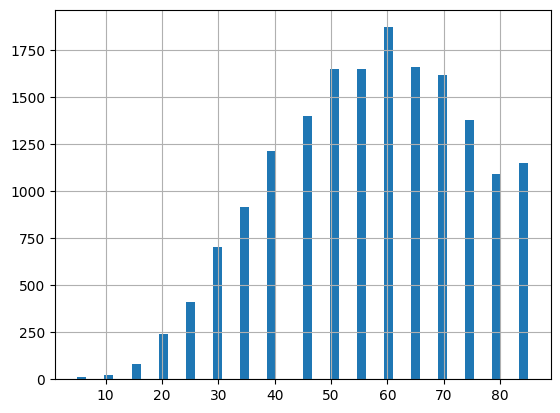

In [356]:
df["age_approx"].hist(bins=50)

In [357]:
df["age_approx"].unique()

array([65., 60., 50., 20., 45., 35., 70., 40., 55., 85., 80., 75., 25.,
       30., 15., 10.,  5.])

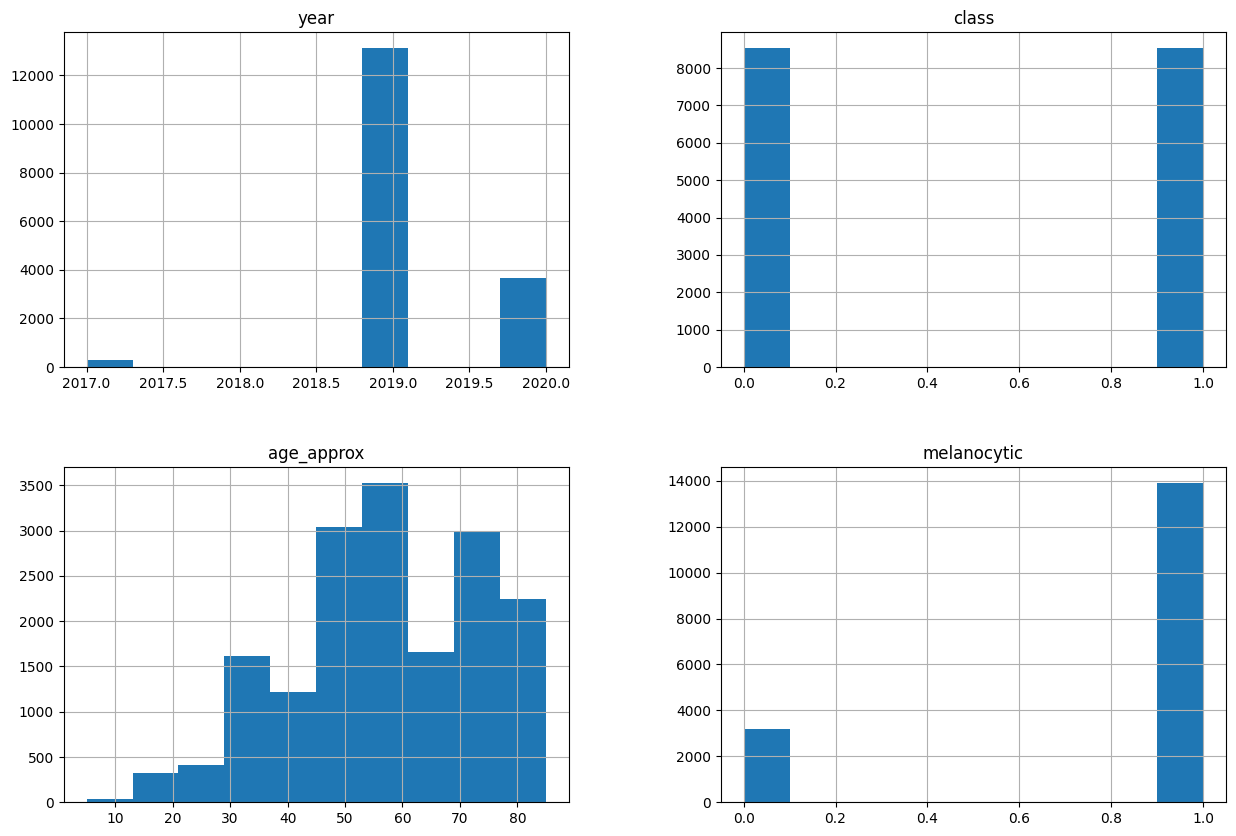

In [358]:
df.hist(figsize=(15, 10))
plt.show()

In [359]:
df.head()

,image,isic_id,year,class,patient_id,lesion_id,sex,age_approx,anatom_site_general,benign_malignant,dermoscopic_type,diagnosis,diagnosis_confirm_type,melanocytic,history_of_mm
0,ISIC2019_0025105_mel.jpg,ISIC_0025105,2019.0,1,Unknown,IL_3060556,male,65.0,posterior torso,malignant,Unknown,melanoma,histopathology,1.0,No
1,ISIC2019_0060266_mel.jpg,ISIC_0060266,2019.0,1,Unknown,IL_7904303,female,60.0,lower extremity,malignant,Unknown,melanoma,histopathology,1.0,No
2,ISIC2019_0067614_mel.jpg,ISIC_0067614,2019.0,1,Unknown,IL_4549035,male,60.0,palms/soles,malignant,Unknown,melanoma,histopathology,1.0,No
3,ISIC2019_0033171_mel.jpg,ISIC_0033171,2019.0,1,Unknown,IL_9013946,male,50.0,anterior torso,malignant,Unknown,melanoma,histopathology,1.0,No
4,ISIC2020_8951909_mel.jpg,ISIC_8951909,2020.0,1,IP_4302652,IL_6277992,female,20.0,lower extremity,malignant,Unknown,melanoma,histopathology,1.0,No


In [360]:
df[df["patient_id"] == "IP_4302652"]

,image,isic_id,year,class,patient_id,lesion_id,sex,age_approx,anatom_site_general,benign_malignant,dermoscopic_type,diagnosis,diagnosis_confirm_type,melanocytic,history_of_mm
4,ISIC2020_8951909_mel.jpg,ISIC_8951909,2020.0,1,IP_4302652,IL_6277992,female,20.0,lower extremity,malignant,Unknown,melanoma,histopathology,1.0,No
4927,ISIC2020_9237193_oth.jpg,ISIC_9237193,2020.0,0,IP_4302652,IL_5129270,female,20.0,posterior torso,benign,Unknown,Unknown,single image expert consensus,1.0,No
6058,ISIC2020_2605880_oth.jpg,ISIC_2605880,2020.0,0,IP_4302652,IL_9002069,female,20.0,upper extremity,benign,Unknown,Unknown,single image expert consensus,1.0,No
6275,ISIC2020_9638386_oth.jpg,ISIC_9638386,2020.0,0,IP_4302652,IL_4246442,female,20.0,lower extremity,benign,Unknown,Unknown,single image expert consensus,1.0,No
6802,ISIC2020_4172423_oth.jpg,ISIC_4172423,2020.0,0,IP_4302652,IL_7559377,female,20.0,anterior torso,benign,Unknown,Unknown,single image expert consensus,1.0,No
7355,ISIC2020_3779532_oth.jpg,ISIC_3779532,2020.0,0,IP_4302652,IL_2687567,female,20.0,posterior torso,benign,Unknown,Unknown,single image expert consensus,1.0,No
16416,ISIC2020_7901098_oth.jpg,ISIC_7901098,2020.0,0,IP_4302652,IL_1485072,female,20.0,upper extremity,benign,Unknown,Unknown,single image expert consensus,1.0,No


In [361]:
df[df["lesion_id"] == "IL_6407384"]

,image,isic_id,year,class,patient_id,lesion_id,sex,age_approx,anatom_site_general,benign_malignant,dermoscopic_type,diagnosis,diagnosis_confirm_type,melanocytic,history_of_mm
77,ISIC2019_0024972_mel.jpg,ISIC_0024972,2019.0,1,Unknown,IL_6407384,female,75.0,head/neck,malignant,Unknown,melanoma,histopathology,1.0,No
2266,ISIC2019_0031779_mel.jpg,ISIC_0031779,2019.0,1,Unknown,IL_6407384,female,75.0,head/neck,malignant,Unknown,melanoma,histopathology,1.0,No


In [362]:
import pandas as pd

df_filtered = df[df["lesion_id"] != "Unknown"]

conflicting_mask = df_filtered.groupby('lesion_id')['class'].transform('nunique') > 1
conflicting_rows = df_filtered[conflicting_mask].sort_values('lesion_id')

if conflicting_rows.empty:
    print("No conflicting classes found for any lesion_id.")
else:
    print(f"Found {conflicting_rows['lesion_id'].nunique()} lesions with conflicting classes:")
    print(conflicting_rows[['isic_id', 'lesion_id', 'class']])

No conflicting classes found for any lesion_id.


In [363]:
df.drop(columns=["lesion_id"], inplace=True)

In [364]:
df["year"] = df["year"].astype("object")
df["age_approx"] = df["age_approx"].astype("int64")
df["melanocytic"] = df["melanocytic"].astype("int64")

In [365]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17059 entries, 0 to 17059
Data columns (total 14 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   image                   17059 non-null  object
 1   isic_id                 17059 non-null  object
 2   year                    17059 non-null  object
 3   class                   17059 non-null  int64 
 4   patient_id              17059 non-null  object
 5   sex                     17059 non-null  object
 6   age_approx              17059 non-null  int64 
 7   anatom_site_general     17059 non-null  object
 8   benign_malignant        17059 non-null  object
 9   dermoscopic_type        17059 non-null  object
 10  diagnosis               17059 non-null  object
 11  diagnosis_confirm_type  17059 non-null  object
 12  melanocytic             17059 non-null  int64 
 13  history_of_mm           17059 non-null  object
dtypes: int64(3), object(11)
memory usage: 2.0+ MB


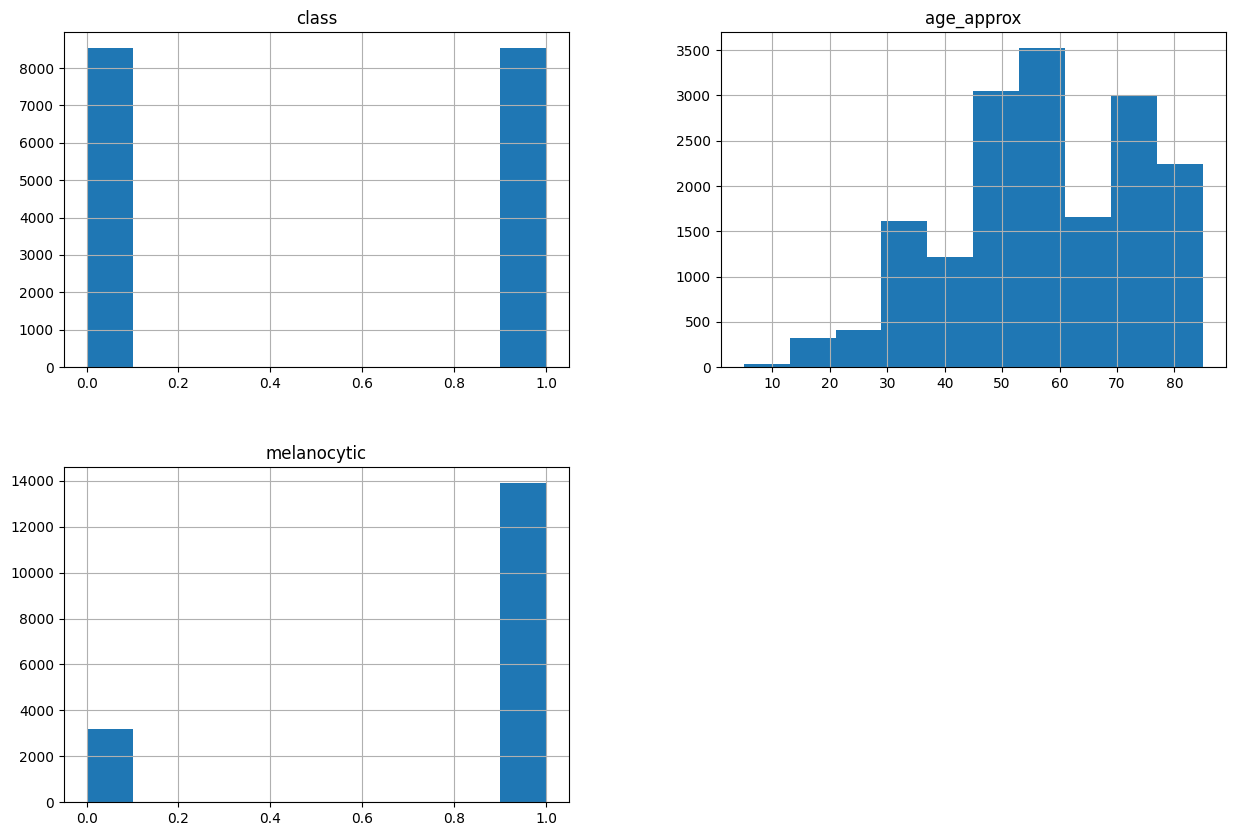

In [366]:
df.hist(figsize=(15, 10))
plt.show()

In [367]:
df['age_group'] = pd.cut(df['age_approx'], bins=[0,20,40,60,85], labels=['0-20', '21-40', '41-60', '61-85'])

In [368]:
df["age_group"].value_counts()

age_group
61-85    6895
41-60    6566
21-40    3242
0-20      356
Name: count, dtype: int64

In [369]:
from sklearn.preprocessing import MinMaxScaler
scaler = MinMaxScaler()
df['age_scaled'] = scaler.fit_transform(df[['age_approx']])

df.drop(columns=["age_approx"], inplace=True)

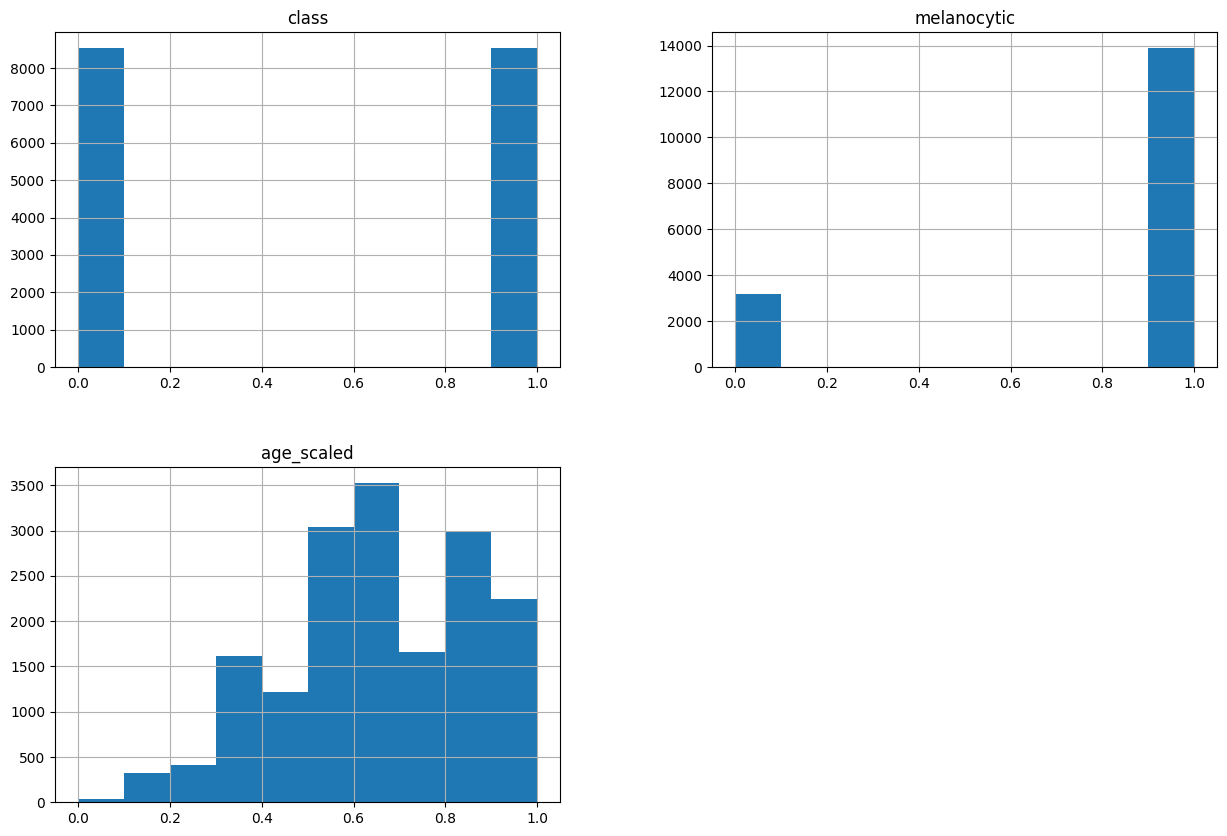

In [370]:
import matplotlib.pyplot as plt
df.hist(figsize=(15, 10))
plt.show()

In [371]:
# import matplotlib.pyplot as plt
# import seaborn as sns
# for col in df.columns[df.dtypes == "object"]:
#     plt.figure(figsize=(10, 5))
#     sns.boxplot(data=df, x=col)
#     plt.title(f"Distribution of {col}")
#     plt.xticks(rotation=45)
#     plt.show()
    

In [372]:
df["diagnosis"].value_counts()

diagnosis
melanoma                              6790
nevus                                 3554
Unknown                               2707
basal cell carcinoma                  1498
squamous cell carcinoma                676
seborrheic keratosis                   349
actinic keratosis                      294
solar lentigo                          204
acrochordon                            167
lichenoid keratosis                    137
pigmented benign keratosis             112
lentigo NOS                             98
atypical melanocytic proliferation      80
AIMP                                    77
dermatofibroma                          72
verruca                                 62
vascular lesion                         44
melanoma metastasis                     36
angioma                                 32
lentigo simplex                         21
neurofibroma                            13
scar                                     9
other                                    8
c

In [373]:
df.loc[df["diagnosis"] == "other", "diagnosis"] = "Unknown"

In [374]:
df["diagnosis"].value_counts()

diagnosis
melanoma                              6790
nevus                                 3554
Unknown                               2715
basal cell carcinoma                  1498
squamous cell carcinoma                676
seborrheic keratosis                   349
actinic keratosis                      294
solar lentigo                          204
acrochordon                            167
lichenoid keratosis                    137
pigmented benign keratosis             112
lentigo NOS                             98
atypical melanocytic proliferation      80
AIMP                                    77
dermatofibroma                          72
verruca                                 62
vascular lesion                         44
melanoma metastasis                     36
angioma                                 32
lentigo simplex                         21
neurofibroma                            13
scar                                     9
clear cell acanthoma                     5
a

In [375]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 17059 entries, 0 to 17059
Data columns (total 15 columns):
 #   Column                  Non-Null Count  Dtype   
---  ------                  --------------  -----   
 0   image                   17059 non-null  object  
 1   isic_id                 17059 non-null  object  
 2   year                    17059 non-null  object  
 3   class                   17059 non-null  int64   
 4   patient_id              17059 non-null  object  
 5   sex                     17059 non-null  object  
 6   anatom_site_general     17059 non-null  object  
 7   benign_malignant        17059 non-null  object  
 8   dermoscopic_type        17059 non-null  object  
 9   diagnosis               17059 non-null  object  
 10  diagnosis_confirm_type  17059 non-null  object  
 11  melanocytic             17059 non-null  int64   
 12  history_of_mm           17059 non-null  object  
 13  age_group               17059 non-null  category
 14  age_scaled              170

In [376]:
# Because they indicate the same information as the "class" column
df.drop(columns=["benign_malignant", "diagnosis"], inplace=True)

In [377]:
columns_to_keep_as_it_is = ["image", "isic_id", "patient_id", "year", "age_scaled", "melanocytic"]

ohe_features = [
    'sex', 
    'anatom_site_general', 
    'dermoscopic_type', 
    'diagnosis_confirm_type', 
    'history_of_mm', 
    'age_group'
]
target_col = ['class']

df_encoded = pd.get_dummies(df, columns=ohe_features, drop_first=False)

encoded_cols = []
for col in df_encoded.columns:
    for base in ohe_features:
        if col.startswith(base + "_"):
            encoded_cols.append(col)
            break

df_ids = df_encoded[columns_to_keep_as_it_is]
df_features = df_encoded[encoded_cols].astype(float)
df_target = df_encoded[target_col].astype(int)
df = pd.concat([df_ids, df_features, df_target], axis=1)

# Summary Outputs
print(f"Total encoded features generated: {len(encoded_cols)}")
print(f"Total columns in final dataframe: {len(df.columns)}")
df.info()

Total encoded features generated: 27
Total columns in final dataframe: 34
<class 'pandas.core.frame.DataFrame'>
Index: 17059 entries, 0 to 17059
Data columns (total 34 columns):
 #   Column                                                                Non-Null Count  Dtype  
---  ------                                                                --------------  -----  
 0   image                                                                 17059 non-null  object 
 1   isic_id                                                               17059 non-null  object 
 2   patient_id                                                            17059 non-null  object 
 3   year                                                                  17059 non-null  object 
 4   age_scaled                                                            17059 non-null  float64
 5   melanocytic                                                           17059 non-null  int64  
 6   sex_Unknown              

In [378]:
analysis_cols = encoded_cols + ['age_scaled', 'melanocytic', 'class']
correlations = df[analysis_cols].corr()
class_corr = correlations["class"].abs().sort_values(ascending=False)
print(class_corr)

class                                                                   1.000000
diagnosis_confirm_type_histopathology                                   0.574699
diagnosis_confirm_type_serial imaging showing no change                 0.409054
age_scaled                                                              0.312430
diagnosis_confirm_type_single image expert consensus                    0.278529
age_group_61-85                                                         0.253314
age_group_21-40                                                         0.200540
diagnosis_confirm_type_Unknown                                          0.169616
anatom_site_general_head/neck                                           0.114346
age_group_0-20                                                          0.112373
history_of_mm_Yes                                                       0.106578
history_of_mm_No                                                        0.106578
anatom_site_general_posterio

In [379]:
df.columns

Index(['image', 'isic_id', 'patient_id', 'year', 'age_scaled', 'melanocytic',
       'sex_Unknown', 'sex_female', 'sex_male', 'anatom_site_general_Unknown',
       'anatom_site_general_anterior torso', 'anatom_site_general_head/neck',
       'anatom_site_general_lateral torso',
       'anatom_site_general_lower extremity',
       'anatom_site_general_oral/genital', 'anatom_site_general_palms/soles',
       'anatom_site_general_posterior torso',
       'anatom_site_general_upper extremity', 'dermoscopic_type_Unknown',
       'dermoscopic_type_contact non-polarized',
       'dermoscopic_type_contact polarized',
       'dermoscopic_type_non-contact polarized',
       'diagnosis_confirm_type_Unknown',
       'diagnosis_confirm_type_confocal microscopy with consensus dermoscopy',
       'diagnosis_confirm_type_histopathology',
       'diagnosis_confirm_type_serial imaging showing no change',
       'diagnosis_confirm_type_single image expert consensus',
       'history_of_mm_No', 'history_o

In [384]:
df.to_csv('final_preprocessed_data.csv', index=False)

### **Visualizations**

### **Feature selection**

In [380]:
# Wrapper methods

from sklearn.feature_selection import RFE, SequentialFeatureSelector
from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score
from sklearn.preprocessing import LabelEncoder, StandardScaler
import matplotlib.pyplot as plt
import pandas as pd
import numpy as np

FEATURES = df.columns.tolist()[:-1]
TARGET = 'class'  

df_w = df[FEATURES + [TARGET]].copy()
for col in df_w.select_dtypes('object').columns:
    df_w[col] = LabelEncoder().fit_transform(df_w[col].astype(str))

X = df_w.drop(columns=[TARGET])
y = df_w[TARGET]

scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(X), columns=X.columns)

estimator = RandomForestClassifier(n_estimators=100, random_state=42,
                                    class_weight='balanced')

RFE
                                                             Feature  Selected  Ranking
                                                               image      True        1
                                                             isic_id      True        1
                                                          patient_id      True        1
                                                          age_scaled      True        1
                               diagnosis_confirm_type_histopathology      True        1
                                                         melanocytic     False        2
             diagnosis_confirm_type_serial imaging showing no change     False        3
                diagnosis_confirm_type_single image expert consensus     False        4
                                                                year     False        5
                                                     age_group_61-85     False        6
                            

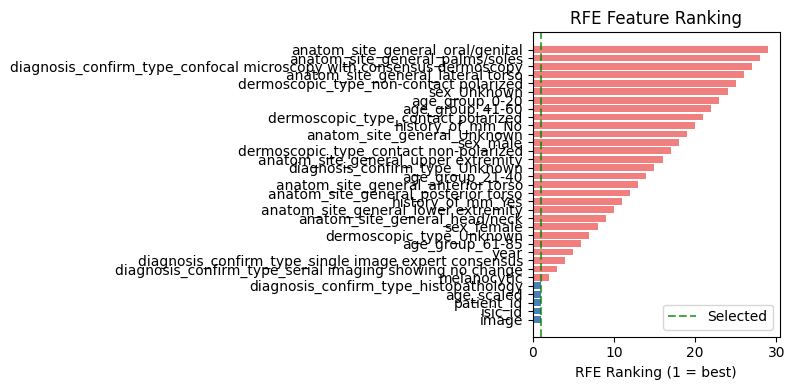

In [ ]:
# 1️⃣  RFE — Recursive Feature Elimination
print("RFE")

# Remove the 'leakage' and 'id' columns before running RFE
rfe_input_cols = [
    col for col in df.columns 
    if col not in ['image', 'isic_id', 'patient_id', 'year', 'class'] 
    and 'diagnosis_confirm_type' not in col 
]

# Run RFE only on X_rfe
X_rfe = df[rfe_input_cols]
y_rfe = df['class']
rfe = RFE(estimator=estimator,
          n_features_to_select=5,   
          step=1)                 

rfe.fit(X_scaled, y)

rfe_results = pd.DataFrame({
    'Feature': X.columns,
    'Selected': rfe.support_,
    'Ranking':  rfe.ranking_
}).sort_values('Ranking')

print(rfe_results.to_string(index=False))
print(f"\nSelected features: {list(X.columns[rfe.support_])}")

rfe_score = cross_val_score(
    estimator, X_scaled[X.columns[rfe.support_]], y,
    cv=5, scoring='roc_auc').mean()
print(f"CV AUC with RFE features: {rfe_score:.4f}")

plt.figure(figsize=(8, 4))
colors = ['steelblue' if s else 'lightcoral' for s in rfe_results['Selected']]
plt.barh(rfe_results['Feature'], rfe_results['Ranking'], color=colors)
plt.xlabel("RFE Ranking (1 = best)")
plt.title("RFE Feature Ranking")
plt.axvline(x=1, color='green', linestyle='--', alpha=0.7, label='Selected')
plt.legend()
plt.tight_layout()
plt.savefig("rfe_ranking.png", dpi=150)
plt.show()


Sequential Forward Selection
Selected features: ['age_scaled', 'melanocytic', 'sex_Unknown', 'dermoscopic_type_Unknown', 'diagnosis_confirm_type_histopathology']
CV AUC with SFS features: 0.8411


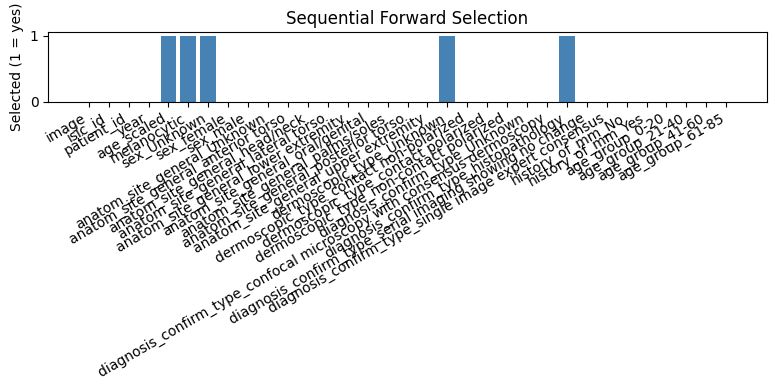

In [382]:
print("Sequential Forward Selection")

sfs = SequentialFeatureSelector(
    estimator=estimator,
    n_features_to_select=5,
    direction='forward',        
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

sfs.fit(X_scaled, y)

sfs_selected = list(X.columns[sfs.get_support()])
print(f"Selected features: {sfs_selected}")

sfs_score = cross_val_score(
    estimator, X_scaled[sfs_selected], y,
    cv=5, scoring='roc_auc').mean()
print(f"CV AUC with SFS features: {sfs_score:.4f}")

plt.figure(figsize=(8, 4))
colors = ['steelblue' if s else 'lightcoral' for s in sfs.get_support()]
plt.bar(X.columns, sfs.get_support().astype(int), color=colors)
plt.ylabel("Selected (1 = yes)")
plt.title("Sequential Forward Selection")
plt.xticks(rotation=30, ha='right')
plt.tight_layout()
plt.savefig("sfs_selected.png", dpi=150)
plt.show()


In [383]:
print("Sequential Backward Elimination")

sbe = SequentialFeatureSelector(
    estimator=estimator,
    n_features_to_select=5,
    direction='backward',     
    scoring='roc_auc',
    cv=5,
    n_jobs=-1
)

sbe.fit(X_scaled, y)

sbe_selected = list(X.columns[sbe.get_support()])
print(f"Selected features: {sbe_selected}")

sbe_score = cross_val_score(
    estimator, X_scaled[sbe_selected], y,
    cv=5, scoring='roc_auc').mean()
print(f"CV AUC with SBE features: {sbe_score:.4f}")


Sequential Backward Elimination


KeyboardInterrupt: 

In [ ]:
from xgboost import XGBClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, roc_auc_score
from sklearn.preprocessing import LabelEncoder
import pandas as pd

FEATURES = df.columns.tolist()[:-1]
TARGET = 'class'

df_model = df[FEATURES + [TARGET]].copy()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(
        df_model[col].fillna('unknown').astype(str))

df_model = df_model.fillna(df_model.median(numeric_only=True))

# تأكد
print("Dtypes:\n", df_model.dtypes)
print("\nNulls:", df_model.isnull().sum().sum())
print("\nClass distribution:\n", df_model[TARGET].value_counts())

X = df_model[FEATURES]
y = df_model[TARGET]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)

model = XGBClassifier(
    n_estimators=300,
    max_depth=6,
    learning_rate=0.05,
    random_state=42,
    eval_metric='auc'
)

model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print("\n", classification_report(y_test, y_pred))
print("AUC:", roc_auc_score(y_test, model.predict_proba(X_test)[:,1]))

C:\Users\Ahmed Mohsen\AppData\Local\Temp\ipykernel_17228\3680791201.py:21: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model[col].fillna('unknown').astype(str))


Dtypes:
 sex                         int32
anatom_site_general         int32
dermoscopic_type            int32
diagnosis                   int32
diagnosis_confirm_type      int32
melanocytic                 int64
history_of_mm               int32
age_scaled                float64
year                        int32
class                       int64
dtype: object

Nulls: 0

Class distribution:
 class
1    8530
0    8529
Name: count, dtype: int64

               precision    recall  f1-score   support

           0       0.98      0.97      0.98      1706
           1       0.98      0.98      0.98      1706

    accuracy                           0.98      3412
   macro avg       0.98      0.98      0.98      3412
weighted avg       0.98      0.98      0.98      3412

AUC: 0.9983675985316289


C:\Users\Ahmed Mohsen\AppData\Local\Temp\ipykernel_17228\3478816546.py:18: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_model[col].fillna('unknown').astype(str))


Feature Importances:
diagnosis                 0.5836
diagnosis_confirm_type    0.2017
age_scaled                0.0536
year                      0.0459
dermoscopic_type          0.0457
melanocytic               0.0367
anatom_site_general       0.0203
history_of_mm             0.0065
sex                       0.0060
dtype: float64


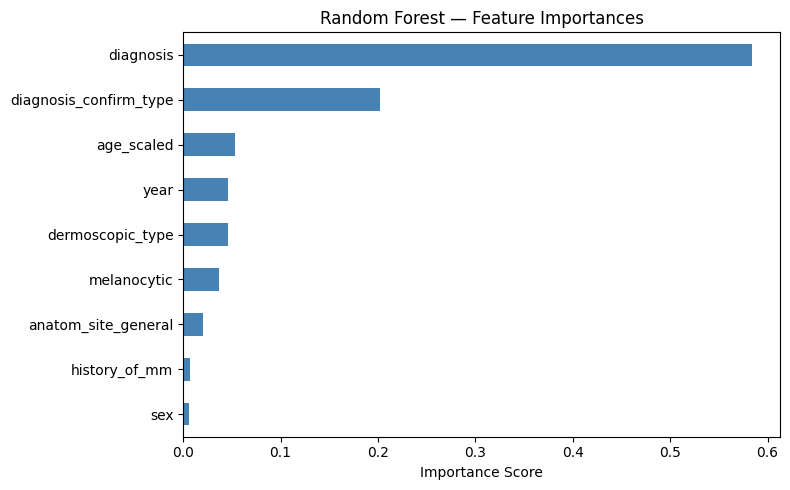

In [ ]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
import pandas as pd

FEATURES = df.columns.tolist()[:-1]

TARGET_COL = 'class'
SEED = 42

df_model = df[FEATURES + [TARGET_COL]].copy()

for col in df_model.select_dtypes(include='object').columns:
    df_model[col] = LabelEncoder().fit_transform(
        df_model[col].fillna('unknown').astype(str))

df_model = df_model.fillna(df_model.median(numeric_only=True))

X = df_model[FEATURES]
y = df_model[TARGET_COL]

model = RandomForestClassifier(random_state=SEED, class_weight='balanced')
model.fit(X, y)

importances = pd.Series(
    model.feature_importances_, index=X.columns
).sort_values(ascending=False)

print("Feature Importances:")
print(importances.round(4))

plt.figure(figsize=(8, 5))
importances.plot(kind='barh', color='steelblue')
plt.gca().invert_yaxis()
plt.xlabel("Importance Score")
plt.title("Random Forest — Feature Importances")
plt.tight_layout()
plt.savefig("rf_importances.png", dpi=150)
plt.show()